In [1]:
import pandas as pd
from pathlib import Path

In [2]:
path = Path("../dl/2/IMDB Dataset.csv")
df = pd.read_csv(path)
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
df["label"] = df.sentiment.map({"positive" : 1, "negative" : 0})
df

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0
49997,I am a Catholic taught in parochial elementary...,negative,0
49998,I'm going to have to disagree with the previou...,negative,0


In [5]:
x = df.review
y = df.label

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
len(x_train)

40000

In [8]:
len(x_test)

10000

In [9]:
from tensorflow import keras
import tensorflow as tf

In [10]:
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 200

vectorizer = keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

In [11]:
text_ds = tf.data.Dataset.from_tensor_slices(x_train).batch(256)

In [12]:
vectorizer.adapt(text_ds)

In [13]:
print("Vocabulary size:", len(vectorizer.get_vocabulary()))
print("First 10 words:", vectorizer.get_vocabulary()[:10])

Vocabulary size: 10000
First 10 words: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it')]


In [14]:
model = keras.Sequential([
    keras.layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    keras.layers.Embedding(input_dim=MAX_TOKENS, output_dim=64),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
x_train = x_train.astype(str).to_numpy()
x_test = x_test.astype(str).to_numpy()

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=7,
    batch_size=128
)

Epoch 1/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7261 - loss: 0.5418 - val_accuracy: 0.8453 - val_loss: 0.3650
Epoch 2/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8687 - loss: 0.3168 - val_accuracy: 0.8656 - val_loss: 0.3136
Epoch 3/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8908 - loss: 0.2673 - val_accuracy: 0.8411 - val_loss: 0.3650
Epoch 4/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9057 - loss: 0.2380 - val_accuracy: 0.8491 - val_loss: 0.3458
Epoch 5/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9195 - loss: 0.2132 - val_accuracy: 0.8633 - val_loss: 0.3320
Epoch 6/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9235 - loss: 0.2018 - val_accuracy: 0.8661 - val_loss: 0.3535
Epoch 7/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9340 - loss: 0.1825 - val_accuracy: 0.8679 - val_loss: 0.3481


In [18]:
import matplotlib.pyplot as plt

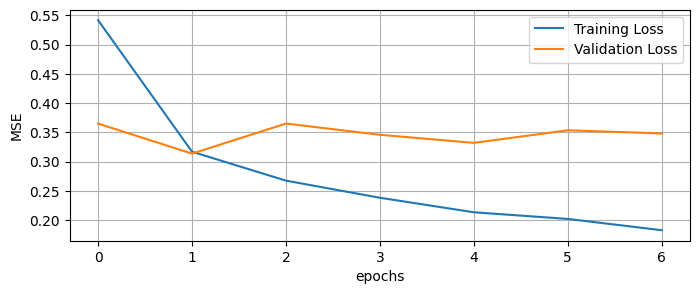

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.grid()
plt.legend()
plt.xlabel("epochs")
plt.ylabel("MSE")
plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8708 - loss: 0.3304


In [26]:
test_loss

0.33044517040252686

In [28]:
test_accuracy

0.8708000183105469

In [31]:
probabilities = model.predict(x_test, verbose=0).flatten()
probabilities
# y_pred = (probabilities >= 0.5).astype(int)

array([0.01940455, 0.98029584, 0.02063592, ..., 0.9679274 , 0.15843324,
       0.92572707], shape=(10000,), dtype=float32)

In [34]:
y_pred = (probabilities >= 0.5).astype(int)
y_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      4961
    positive       0.86      0.89      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



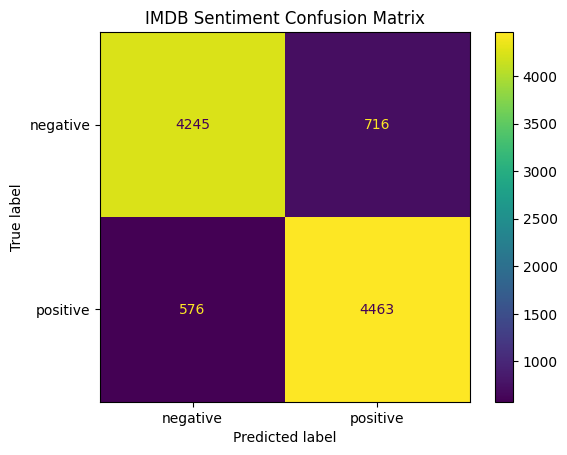

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)
display.plot()
plt.title("IMDB Sentiment Confusion Matrix")
plt.show()